# Macrostate models

In [5]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd



import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm


from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### PCCA: populations, metastability, coherence

In [3]:
#-----------
tica_lag = 100 # lag time for TICA in frames, 1000 frames = 200 nanoseconds
tica_dim_distances = 5
tica_dim_dihedrals = 7
pca_dim_distances = 5
pca_dim_dihedrals = 7
tica_dihedrals = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_dihedrals}_dihedrals.npy")
pca_dihedrals = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_dihedrals}_dihedrals.npy")
tica_distances = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_distances}_distances.npy")
pca_distances = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_distances}_distances.npy")


trajectories = [tica_distances, pca_distances, tica_dihedrals, pca_dihedrals]
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]
#------------

total_time_micros = 300
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames





macrostates_dict = {
    "tica_distances": 5,
    "pca_distances": 3,
    "tica_dihedrals": 10,
    "pca_dihedrals": 4
}


clean_traj_pcca_assignments_dict = {}
for i, name in enumerate(trajectories_labels):
    n_macro = macrostates_dict[name]
    clean_traj_pcca_assignments_dict[name] = np.load(f"../intermediate_outputs/pcca/{n_macro}macro_{name}_clean_assignments.npy")

Time step (microseconds) 0.00019658711659778472
Time step (nanoseconds) 0.19658711659778472
Time step (picoseconds) 196.58711659778473
One microsecond in frames 5086


In [4]:
print(np.unique(clean_traj_pcca_assignments_dict["tica_distances"]))

[0 1 2 3 4]


---
#### Build markov model to estimate self-transition probabilities (metastability)

In [6]:
msm_lag = 100 # same as for microstate msm

estimator_counts = TransitionCountEstimator(lagtime=int(msm_lag), count_mode="sliding-effective")

estimator_transition = MaximumLikelihoodMSM(reversible=True, stationary_distribution_constraint=None)


macro_msm_dict = {}
for i, name in enumerate(trajectories_labels):
    n_macro = macrostates_dict[name]
    traj_pcca_assignments = clean_traj_pcca_assignments_dict[name]

    macro_counts = estimator_counts.fit(traj_pcca_assignments).fetch_model()
    macro_msm_dict[name] = estimator_transition.fit(macro_counts).fetch_model()

In [8]:
for name in trajectories_labels:
    print(f"{name}:")
    print("Transition matrix diagonal:")
    print(np.diag(macro_msm_dict[name].transition_matrix))
    print("Stationary distribution:")
    print(macro_msm_dict[name].stationary_distribution)
    print("Timescales (in frames):")
    print(macro_msm_dict[name].timescales(k=10))
    print("\n")

tica_distances:
Transition matrix diagonal:
[0.91781531 0.77044871 0.82456165 0.86007148 0.99022733]
Stationary distribution:
[0.0075545  0.03376863 0.09599316 0.1822874  0.68039631]
Timescales (in frames):
[3505.64048373 1134.69358722  410.54591766  271.38658914]


pca_distances:
Transition matrix diagonal:
[0.63961662 0.94393415 0.98996835]
Stationary distribution:
[0.04285764 0.27697552 0.68016684]
Timescales (in frames):
[3359.95021734  197.58995447]


tica_dihedrals:
Transition matrix diagonal:
[0.8622873  0.72380526 0.95076924 0.80850494 0.87802713 0.63471985
 0.77820773 0.84427113 0.95968516 0.94849126]
Stationary distribution:
[0.00164431 0.00290013 0.00761309 0.00970112 0.01904997 0.08294179
 0.14410285 0.04830845 0.31294292 0.37079535]
Timescales (in frames):
[3933.87285918 2043.15897713 1719.22114142 1127.51656927  681.21266102
  481.94702354  381.99016668  261.25530605  134.43405465]


pca_dihedrals:
Transition matrix diagonal:
[0.70160294 0.9343112  0.92826623 0.9577588 ]


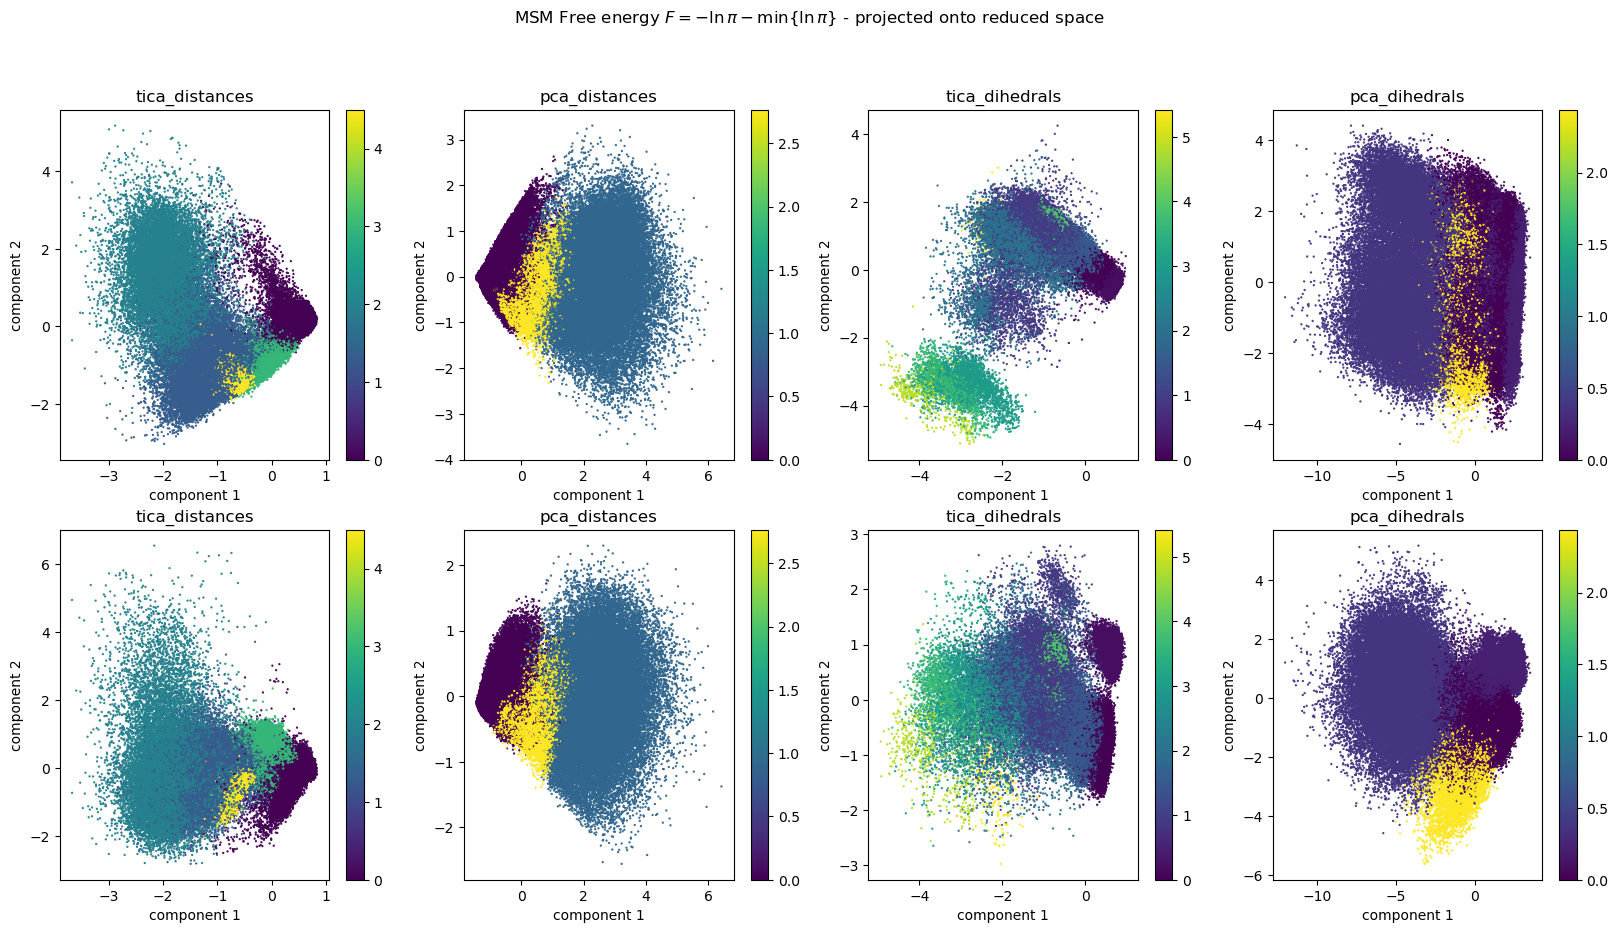

In [9]:
# plot stationary distribution of macrostates

fig, axs = plt.subplots(nrows = 2, ncols = 4, figsize=(20, 10))


for i, name in enumerate(trajectories_labels):

    traj = clean_traj_pcca_assignments_dict[name]
    pi = macro_msm_dict[name].stationary_distribution

    # transform  to free energy
    F = np.full_like(pi, np.nan)
    mask = pi > 0
    F[mask] = -np.log(pi[mask])
    F -= np.nanmin(F)

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = F[traj[mask]]



    ax = axs[0, i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 1][::10], c = z_values[::10], cmap = "viridis", s=0.4, alpha=1)
    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")


    ax = axs[1, i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 3][::10], c = z_values[::10], cmap = "viridis", s=0.4, alpha=1)
    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")


plt.suptitle(r"MSM Free energy $F = -\ln{\pi} - \min\{{\ln{\pi}}\}$ - projected onto reduced space")   
plt.show()

### correspondence between the description: Sankey diagrams

In [10]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go


def sankey_from_macrostate_assignments(assignments, model_names=None, ignore_state=-1):
    """
    assignments: list of 1D arrays, one per model.
                 All arrays must have same length and be frame-aligned.
    model_names: list of names for the models.
    ignore_state: state label to ignore, e.g. -1 for unassigned frames.
    """

    assignments = [np.asarray(a) for a in assignments]

    if len(set(len(a) for a in assignments)) != 1:
        raise ValueError("All assignment arrays must have the same length.")

    n_models = len(assignments)

    if model_names is None:
        model_names = [f"model {i+1}" for i in range(n_models)]

    # Nodes: one node per (model, macrostate)
    node_labels = []
    node_index = {}

    for m, a in enumerate(assignments):
        states = np.unique(a)
        states = states[states != ignore_state]

        for s in states:
            label = f"{model_names[m]}: state {s}"
            node_index[(m, s)] = len(node_labels)
            node_labels.append(label)

    # Links: transition counts between neighbouring models
    sources, targets, values = [], [], []

    for m in range(n_models - 1):
        a = assignments[m]
        b = assignments[m + 1]

        valid = (a != ignore_state) & (b != ignore_state)

        pairs, counts = np.unique(
            np.column_stack([a[valid], b[valid]]),
            axis=0,
            return_counts=True,
        )

        for (s1, s2), count in zip(pairs, counts):
            sources.append(node_index[(m, s1)])
            targets.append(node_index[(m + 1, s2)])
            values.append(count)

    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=15,
                    thickness=15,
                    label=node_labels,
                ),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                ),
            )
        ]
    )

    fig.update_layout(
        title="Correspondence between macrostate assignments across models",
        font_size=12,
        width=1200,
        height=600,
    )

    return fig

In [ ]:
assignments = [clean_pcca_assignments_dict[name] for name in trajectories_labels]
model_names = [



fig = sankey_from_macrostate_assignments(assignments, model_names)
fig.show()